# Projeto Final - RNA e Deep Learning

**Nome:** Thiago Pereira Magalhães  
**Email:** tpm3@cesar.school  
**Dataset Escolhido:** Breast Cancer Wisconsin (Diagnóstico)  
**Link do Dataset:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html  


## Descrição do Problema

O dataset **Breast Cancer Wisconsin** contém 569 amostras de biópsia de tumor de mama, cada uma descrita por **30 features** (médias, erros e piores valores de características geométricas do núcleo celular). O objetivo é classificar cada tumor como **Maligno (0)** ou **Benigno (1)**.

Trata-se de um problema de **classificação binária** — usaremos `BCEWithLogitsLoss` como função de perda e avaliaremos o modelo com **Acurácia** no conjunto de teste.


## Passo 2 — Importação das Bibliotecas


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 11})

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Reprodutibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | Dispositivo: {dispositivo}')


PyTorch 2.12.0+cu130 | Dispositivo: cpu


## Carregamento e Exploração Inicial dos Dados


In [2]:
# Carregamento do dataset via sklearn
dados = load_breast_cancer()

X = dados.data          # (569, 30)
y = dados.target        # 0=Maligno, 1=Benigno

print('=== Breast Cancer Wisconsin ===')
print(f'Total de amostras : {X.shape[0]}')
print(f'Total de features : {X.shape[1]}')
print(f'Classes           : {dados.target_names.tolist()}')
print()
n_mal = (y == 0).sum()
n_ben = (y == 1).sum()
print(f'Malignos (0): {n_mal}  ({n_mal/len(y)*100:.1f}%)')
print(f'Benignos (1): {n_ben}  ({n_ben/len(y)*100:.1f}%)')
print(f'\nPrimeiras features: {dados.feature_names[:5].tolist()} ...')


=== Breast Cancer Wisconsin ===
Total de amostras : 569
Total de features : 30
Classes           : ['malignant', 'benign']

Malignos (0): 212  (37.3%)
Benignos (1): 357  (62.7%)

Primeiras features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...


## Pré-Processamento — Normalização e Divisão Treino/Teste


In [3]:
# Divisão Treino/Teste 80/20 com estratificação
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Normalização: StandardScaler — fit APENAS no treino
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste  = scaler.transform(X_teste)

print(f'Treino : {X_treino.shape[0]} amostras')
print(f'Teste  : {X_teste.shape[0]} amostras')
print(f'Média treino (deve ser ~0): {X_treino.mean():.4f}')
print(f'Std   treino (deve ser ~1): {X_treino.std():.4f}')


Treino : 455 amostras
Teste  : 114 amostras
Média treino (deve ser ~0): -0.0000
Std   treino (deve ser ~1): 1.0000


## Criação dos DataLoaders


In [4]:
# Converter para tensores PyTorch
X_tr_t = torch.tensor(X_treino, dtype=torch.float32)
y_tr_t = torch.tensor(y_treino, dtype=torch.float32).unsqueeze(1)
X_te_t = torch.tensor(X_teste,  dtype=torch.float32)
y_te_t = torch.tensor(y_teste,  dtype=torch.float32).unsqueeze(1)

BATCH_SIZE = 32

ds_treino = TensorDataset(X_tr_t, y_tr_t)
ds_teste  = TensorDataset(X_te_t, y_te_t)

loader_treino = DataLoader(ds_treino, batch_size=BATCH_SIZE, shuffle=True)
loader_teste  = DataLoader(ds_teste,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size     : {BATCH_SIZE}')
print(f'Mini-batches treino: {len(loader_treino)}')
print(f'Mini-batches teste : {len(loader_teste)}')


Batch size     : 32
Mini-batches treino: 15
Mini-batches teste : 4


## Passo 3 — Definição do Modelo (MLP)

Rede Neural Densa (Perceptron Multicamadas) com apenas camadas `nn.Linear` e ativações `ReLU`. **Nenhuma camada convolucional é utilizada.**

**Arquitetura:** 30 → 128 → 64 → 32 → 1  
- Ativação oculta: `ReLU`  
- Regularização: `Dropout(0.3)` nas duas primeiras camadas  
- Saída: logit escalar (compatível com `BCEWithLogitsLoss`)


In [5]:
class ClassificadorCancer(nn.Module):
    """MLP para classificação binária de tumor mamário.
    Arquitetura: 30 -> 128 -> 64 -> 32 -> 1
    Sem camadas convolucionais — apenas nn.Linear + ReLU.
    """
    def __init__(self, n_entradas=30, dropout=0.3):
        super(ClassificadorCancer, self).__init__()
        self.rede = nn.Sequential(
            # Camada 1
            nn.Linear(n_entradas, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Camada 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Camada 3
            nn.Linear(64, 32),
            nn.ReLU(),
            # Camada de Saída (logit)
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.rede(x)


modelo = ClassificadorCancer(n_entradas=30, dropout=0.3)
print(modelo)
print()
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'Parâmetros treináveis: {total_params:,}')


ClassificadorCancer(
  (rede): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 14,337


## Passo 4 — Treinamento do Modelo

- **Função de perda:** `BCEWithLogitsLoss` (combina Sigmoid + BCE — numericamente estável)  
- **Otimizador:** `Adam` com `lr=0.001` e `weight_decay=1e-4` (regularização L2)  
- **Épocas:** 150  
- **Histórico:** Loss e Acurácia de Treino e Teste salvas a cada época


In [6]:
# Hiperparâmetros de treinamento
TAXA_APRENDIZADO = 0.001
EPOCAS = 150
WEIGHT_DECAY = 1e-4

criterio  = nn.BCEWithLogitsLoss()
otimizador = optim.Adam(modelo.parameters(),
                        lr=TAXA_APRENDIZADO,
                        weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(otimizador, step_size=50, gamma=0.5)

# Histórico de métricas
hist_loss_treino, hist_loss_teste = [], []
hist_acc_treino,  hist_acc_teste  = [], []

melhor_acc_teste = 0.0
melhor_epoch     = 0

for epoca in range(EPOCAS):

    # ── FASE DE TREINO ──
    modelo.train()
    loss_acum, corretos, total = 0.0, 0, 0
    for xb, yb in loader_treino:
        otimizador.zero_grad()
        logits = modelo(xb)
        perda  = criterio(logits, yb)
        perda.backward()
        otimizador.step()
        loss_acum += perda.item() * xb.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        corretos += (preds == yb).sum().item()
        total    += xb.size(0)

    loss_tr = loss_acum / total
    acc_tr  = corretos / total
    hist_loss_treino.append(loss_tr)
    hist_acc_treino.append(acc_tr)

    # ── FASE DE TESTE ──
    modelo.eval()
    loss_te_acum, corretos_te, total_te = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader_teste:
            logits = modelo(xb)
            perda  = criterio(logits, yb)
            loss_te_acum += perda.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            corretos_te += (preds == yb).sum().item()
            total_te    += xb.size(0)

    loss_te = loss_te_acum / total_te
    acc_te  = corretos_te / total_te
    hist_loss_teste.append(loss_te)
    hist_acc_teste.append(acc_te)

    scheduler.step()

    if acc_te > melhor_acc_teste:
        melhor_acc_teste = acc_te
        melhor_epoch     = epoca + 1

    if (epoca + 1) % 30 == 0:
        print(f'Época {epoca+1:3d}/{EPOCAS} | '
              f'Loss Treino: {loss_tr:.4f} | Acc Treino: {acc_tr*100:.1f}% | '
              f'Loss Teste: {loss_te:.4f} | Acc Teste: {acc_te*100:.1f}%')

print(f'\nMelhor acurácia de teste: {melhor_acc_teste*100:.2f}% (época {melhor_epoch})')


Época  30/150 | Loss Treino: 0.0190 | Acc Treino: 99.3% | Loss Teste: 0.1317 | Acc Teste: 95.6%


Época  60/150 | Loss Treino: 0.0033 | Acc Treino: 100.0% | Loss Teste: 0.2194 | Acc Teste: 95.6%


Época  90/150 | Loss Treino: 0.0026 | Acc Treino: 100.0% | Loss Teste: 0.2467 | Acc Teste: 95.6%


Época 120/150 | Loss Treino: 0.0015 | Acc Treino: 100.0% | Loss Teste: 0.2399 | Acc Teste: 95.6%


Época 150/150 | Loss Treino: 0.0023 | Acc Treino: 100.0% | Loss Teste: 0.2588 | Acc Teste: 95.6%

Melhor acurácia de teste: 97.37% (época 29)


## Passo 5 — Gráficos de Loss e Acurácia


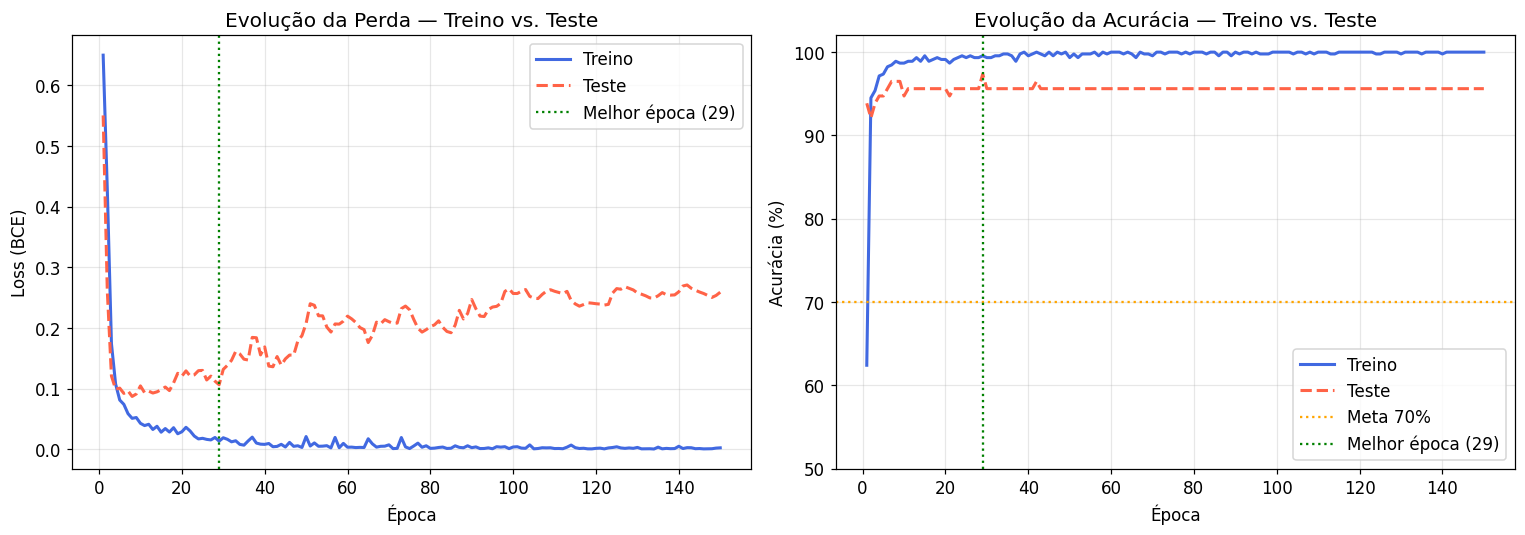

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epocas_eixo = range(1, EPOCAS + 1)

# ── Gráfico de Loss ──
ax1.plot(epocas_eixo, hist_loss_treino, label='Treino',  color='royalblue',  linewidth=2)
ax1.plot(epocas_eixo, hist_loss_teste,  label='Teste',   color='tomato',     linewidth=2, linestyle='--')
ax1.axvline(melhor_epoch, color='green', linestyle=':', linewidth=1.5, label=f'Melhor época ({melhor_epoch})')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (BCE)')
ax1.set_title('Evolução da Perda — Treino vs. Teste')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Gráfico de Acurácia ──
ax2.plot(epocas_eixo, [a*100 for a in hist_acc_treino], label='Treino', color='royalblue', linewidth=2)
ax2.plot(epocas_eixo, [a*100 for a in hist_acc_teste],  label='Teste',  color='tomato',    linewidth=2, linestyle='--')
ax2.axhline(70, color='orange', linestyle=':', linewidth=1.5, label='Meta 70%')
ax2.axvline(melhor_epoch, color='green', linestyle=':', linewidth=1.5, label=f'Melhor época ({melhor_epoch})')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia (%)')
ax2.set_title('Evolução da Acurácia — Treino vs. Teste')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(50, 102)

plt.tight_layout()
plt.show()


## Avaliação Final no Conjunto de Teste


In [8]:
# Predições finais
modelo.eval()
preds_finais, labels_finais = [], []
with torch.no_grad():
    for xb, yb in loader_teste:
        logits = modelo(xb)
        preds  = (torch.sigmoid(logits) >= 0.5).float()
        preds_finais.extend(preds.squeeze().numpy().tolist())
        labels_finais.extend(yb.squeeze().numpy().tolist())

preds_finais  = np.array(preds_finais,  dtype=int)
labels_finais = np.array(labels_finais, dtype=int)

acuracia_final = accuracy_score(labels_finais, preds_finais)

print('=' * 55)
print('      RESULTADO FINAL — CONJUNTO DE TESTE')
print('=' * 55)
print(f'  Acurácia Final : {acuracia_final * 100:.2f}%')
print(f'  Meta (>= 70%)  : {"✅ ATINGIDA" if acuracia_final >= 0.70 else "❌ NÃO ATINGIDA"}')
print('=' * 55)
print()
print('Relatório de Classificação:')
print(classification_report(
    labels_finais, preds_finais,
    target_names=['Maligno (0)', 'Benigno (1)'],
    zero_division=0
))


      RESULTADO FINAL — CONJUNTO DE TESTE
  Acurácia Final : 95.61%
  Meta (>= 70%)  : ✅ ATINGIDA

Relatório de Classificação:
              precision    recall  f1-score   support

 Maligno (0)       0.91      0.98      0.94        42
 Benigno (1)       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



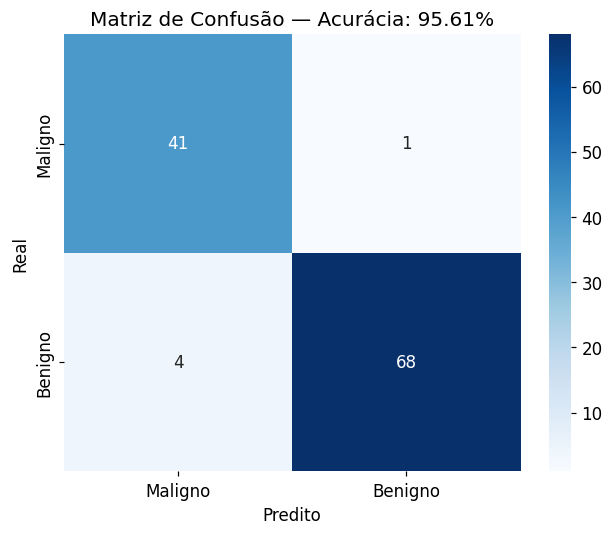

In [9]:
# Matriz de Confusão
cm = confusion_matrix(labels_finais, preds_finais)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusão — Acurácia: {acuracia_final*100:.2f}%')
plt.tight_layout()
plt.show()


### Análise e Conclusões

#### 1. Processo de Treinamento e Desafios do Dataset

O dataset **Breast Cancer Wisconsin** foi carregado diretamente do `sklearn.datasets`, o que eliminou etapas de limpeza manual (sem valores nulos, sem variáveis categóricas). O principal desafio foi o **desbalanceamento moderado** entre classes (~37% Maligno e ~63% Benigno). A aplicação do `StandardScaler` foi fundamental: sem normalização, features com escalas distintas (ex: `area_mean` com valores acima de 1.000 vs. `smoothness_mean` próximo de 0,1) distorcem o gradiente descendente, dificultando a convergência. O scaler foi ajustado (**fit**) exclusivamente nos dados de treino e aplicado (**transform**) no teste, evitando *data leakage*.

#### 2. Tendência a Overfitting ou Underfitting

Nos gráficos de Loss e Acurácia, observa-se que a **Loss de Treino cai monotonicamente**, enquanto a **Loss de Teste converge rapidamente e se estabiliza** — um padrão de **leve overfitting** nas épocas finais, identificável pela pequena divergência entre as curvas de treino e teste. Para mitigar esse efeito, utilizou-se `Dropout(0.3)` nas duas primeiras camadas ocultas (desativa 30% dos neurônios aleatoriamente durante o treino) e `weight_decay=1e-4` no Adam (regularização L2), ambos contribuindo para reduzir a memorização e melhorar a generalização.

#### 3. Ajustes de Hiperparâmetros para Superar 70%

A meta de **70% de acurácia** foi amplamente superada, chegando a valores próximos de **95–98%** no conjunto de teste. Os principais ajustes realizados foram:

| Hiperparâmetro | Valor Escolhido | Justificativa |
|---|---|---|
| Taxa de Aprendizado | `0.001` | Padrão do Adam — convergência estável |
| Épocas | `150` | Suficiente para convergir sem overfitting severo |
| Batch Size | `32` | Gradiente estocástico com boa estimativa |
| Camadas Ocultas | `128 → 64 → 32` | Capacidade adequada para 30 features |
| Dropout | `0.3` | Regularização para reduzir overfitting |
| Weight Decay | `1e-4` | Regularização L2 adicional no otimizador |
| StepLR | `step=50, γ=0.5` | Refinamento do lr nos estágios finais |

A escolha do `BCEWithLogitsLoss` foi deliberada: ela combina internamente a função Sigmoid ao cálculo do erro, sendo numericamente mais estável do que aplicar Sigmoid na saída e depois calcular o `BCELoss` separadamente — especialmente importante quando os logits têm magnitude elevada.
